Loading dataset from face_dataset...
done in 0.223s
Dataset size: n_samples: 64, n_features: 19200
Skipped files: 0


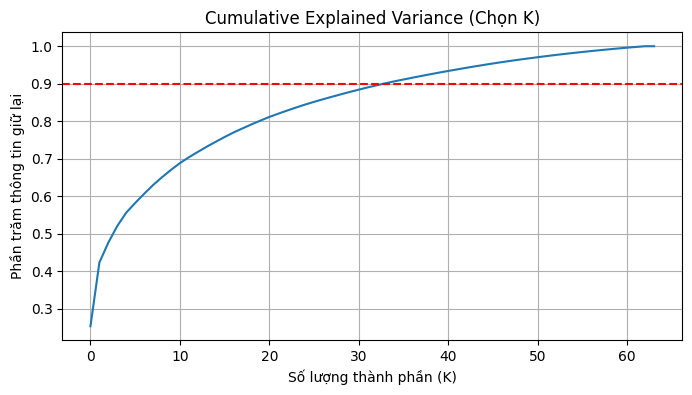

Selected K = 34 to explain 90% of variance
Extracting the top 34 eigenfaces...
Saved Requirement 1: face_new\face_new.png
Saved Requirement 2: myface.png
Saved Requirement 3: myface_and_otherface.png

--- Quantitative Analysis ---
My Face K-dim vector (first 5 elements): [-0.4947  0.7042 -0.8527 -0.2879  0.3246]
Match 1 (102230119.jpg): Distance = 3.5163
   Vector (first 5 elements): [ 0.0788  0.386  -0.29    0.2797 -0.0475]
Match 2 (102230187.png): Distance = 3.5848
   Vector (first 5 elements): [-0.3913  0.8273 -1.0188 -0.38    0.7278]
Match 3 (102230185.jpg): Distance = 3.8529
   Vector (first 5 elements): [-0.4791  0.2057 -0.8847  0.5595 -0.0431]


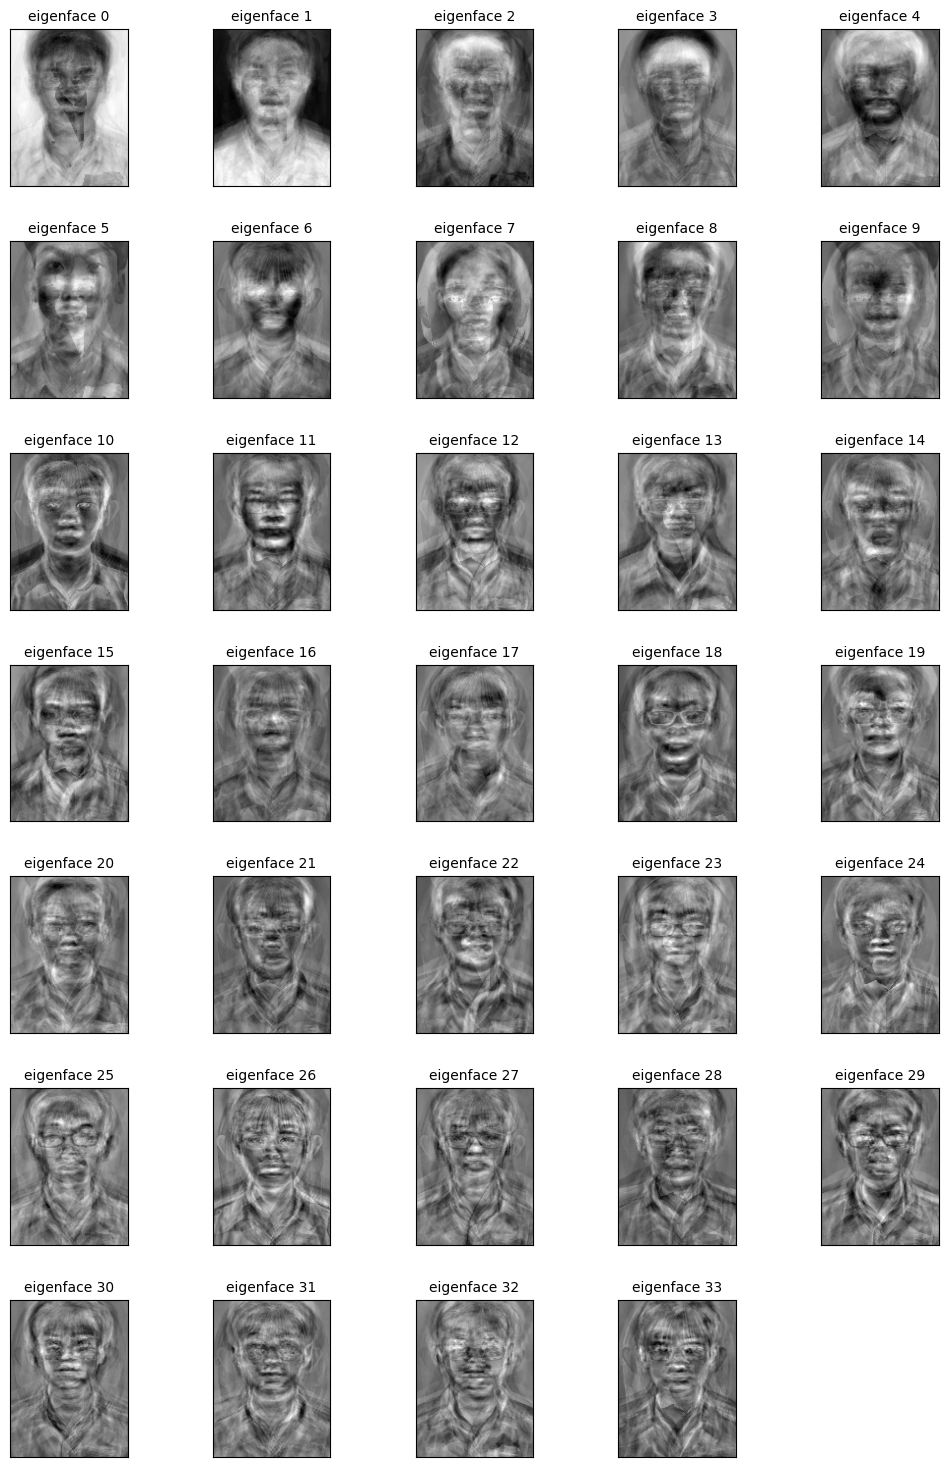

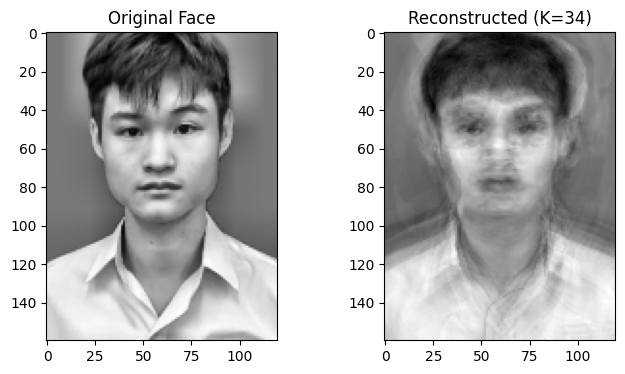

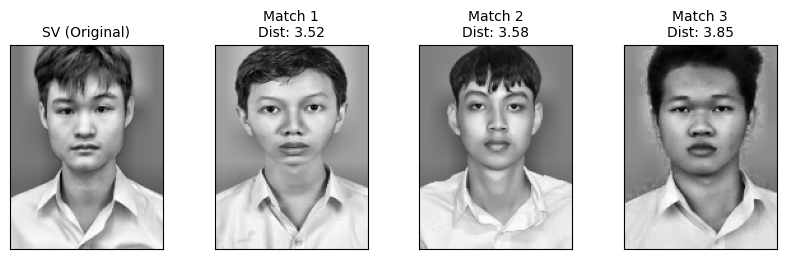

In [31]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from time import time
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Bước 0: Cấu hình thông số ---
DATASET_PATH = "face_dataset"
MY_FACE_PATH = "myface/102230279.jpg"
H, W = 160, 120  # Giữ tỉ lệ 3x4 (cm hoặc ratio)
OUTPUT_EIGEN_DIR = "face_new"
VAR_TARGET = 0.9
RECON_MSE_TARGET = None  # Ví dụ: 0.05 để chọn K theo lỗi tái tạo

# --- Preprocessing options ---
FACE_DETECT = True
STRICT_FACE_DETECT = False  # True: bỏ ảnh không nhận diện được mặt
FACE_SCALE_FACTOR = 1.1
FACE_MIN_NEIGHBORS = 5
MIN_FACE_SIZE = (60, 60)
MIN_IMAGE_SIZE = (80, 80)
FACE_PADDING = 0.20
USE_CLAHE = True
DENOISE_METHOD = "median"  # "median" or "gaussian"
DENOISE_KSIZE = 3

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Hàm bổ trợ vẽ lưới ảnh giống ví dụ sklearn"""
    plt.figure(figsize=(2.0 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0.05, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i in range(min(len(images), n_row * n_col)):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=10)
        plt.xticks(())
        plt.yticks(())

def load_face_cascade():
    candidate_paths = [
        os.path.join(cv2.data.haarcascades, "haarcascade_frontalface_default.xml"),
        os.path.join(os.path.dirname(cv2.__file__), "data", "haarcascade_frontalface_default.xml"),
    ]
    for candidate in candidate_paths:
        if os.path.exists(candidate):
            cascade = cv2.CascadeClassifier(candidate)
            if not cascade.empty():
                return cascade, candidate
    return None, None

def center_crop(img, crop_ratio=0.75):
    height, width = img.shape[:2]
    crop_h = max(1, int(height * crop_ratio))
    crop_w = max(1, int(width * crop_ratio))
    y1 = max(0, (height - crop_h) // 2)
    x1 = max(0, (width - crop_w) // 2)
    return img[y1:y1 + crop_h, x1:x1 + crop_w]

def extract_face(path, cascade):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    if img.shape[0] < MIN_IMAGE_SIZE[1] or img.shape[1] < MIN_IMAGE_SIZE[0]:
        return None

    face_img = None
    if FACE_DETECT and cascade is not None:
        faces = cascade.detectMultiScale(
            img,
            scaleFactor=FACE_SCALE_FACTOR,
            minNeighbors=FACE_MIN_NEIGHBORS,
            minSize=MIN_FACE_SIZE,
        )
        if len(faces) > 0:
            x, y, w, h = max(faces, key=lambda r: r[2] * r[3])
            pad_x = int(w * FACE_PADDING)
            pad_y = int(h * FACE_PADDING)
            x1 = max(0, x - pad_x)
            y1 = max(0, y - pad_y)
            x2 = min(img.shape[1], x + w + pad_x)
            y2 = min(img.shape[0], y + h + pad_y)
            face_img = img[y1:y2, x1:x2]
        elif STRICT_FACE_DETECT:
            return None

    if face_img is None:
        face_img = center_crop(img, crop_ratio=0.75)

    if USE_CLAHE:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        face_img = clahe.apply(face_img)

    if DENOISE_METHOD == "median":
        face_img = cv2.medianBlur(face_img, DENOISE_KSIZE)
    elif DENOISE_METHOD == "gaussian":
        k = DENOISE_KSIZE
        face_img = cv2.GaussianBlur(face_img, (k, k), 0)

    face_img = cv2.resize(face_img, (W, H))
    return face_img

# --- Bước 1: Load dữ liệu và Tiền xử lý ---
print("Loading dataset from %s..." % DATASET_PATH)
t0 = time()
data = []
file_names = []
skipped_files = 0

face_cascade, face_cascade_path = load_face_cascade()
if face_cascade is None:
    FACE_DETECT = False
    print("Warning: Could not load Haar cascade. Using center crop fallback.")
else:
    print("Using Haar cascade:", face_cascade_path)

for file in os.listdir(DATASET_PATH):
    if file.endswith((".jpg", ".png", ".jpeg")):
        img_path = os.path.join(DATASET_PATH, file)
        img_res = extract_face(img_path, face_cascade)
        if img_res is None:
            skipped_files += 1
            continue
        data.append(img_res.flatten())
        file_names.append(file)

if len(data) == 0:
    raise ValueError("No valid face images found after preprocessing.")

X = np.array(data).astype(np.float32)
n_samples, n_features = X.shape

# Load ảnh của chính sinh viên
my_img = extract_face(MY_FACE_PATH, face_cascade)
if my_img is None:
    raise ValueError("Student image could not be processed.")
my_img_res = my_img.flatten().reshape(1, -1)

print("done in %0.3fs" % (time() - t0))
print("Dataset size: n_samples: %d, n_features: %d" % (n_samples, n_features))
print("Skipped files: %d" % skipped_files)

# Chuẩn hóa dữ liệu (Bước 1 của quy trình PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
my_face_scaled = scaler.transform(my_img_res)

# --- Bước 2: Phân tích phương sai để chọn K ---
pca_full = PCA(svd_solver='full').fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(cum_var)
plt.axhline(y=VAR_TARGET, color='r', linestyle='--')
plt.title("Cumulative Explained Variance (Chọn K)")
plt.xlabel("Số lượng thành phần (K)")
plt.ylabel("Phần trăm thông tin giữ lại")
plt.grid(True)
plt.show()

# Chọn K: ưu tiên theo lỗi tái tạo nếu có đặt RECON_MSE_TARGET
if RECON_MSE_TARGET is not None:
    max_k = min(n_samples, n_features)
    mse_list = []
    K = max_k
    for k in range(1, max_k + 1):
        pca_tmp = PCA(n_components=k, svd_solver="randomized", whiten=True).fit(X_scaled)
        X_rec = pca_tmp.inverse_transform(pca_tmp.transform(X_scaled))
        mse = np.mean((X_scaled - X_rec) ** 2)
        mse_list.append(mse)
        if mse <= RECON_MSE_TARGET:
            K = k
            break
    print("Selected K = %d to reach MSE <= %.6f" % (K, RECON_MSE_TARGET))
else:
    K = np.argmax(cum_var >= VAR_TARGET) + 1
    print("Selected K = %d to explain %.0f%% of variance" % (K, VAR_TARGET * 100))

# --- YÊU CẦU 1: Xuất file face_new chứa K Eigenfaces ---
print("Extracting the top %d eigenfaces..." % K)
pca = PCA(n_components=K, svd_solver="randomized", whiten=True).fit(X_scaled)
eigenfaces = pca.components_

# Tạo folder lưu eigenfaces
os.makedirs(OUTPUT_EIGEN_DIR, exist_ok=True)

# Lưu lưới ảnh Eigenfaces
eigen_titles = ["eigenface %d" % i for i in range(K)]
plot_gallery(eigenfaces, eigen_titles, H, W, n_row=int(K/5)+1, n_col=5)
grid_path = os.path.join(OUTPUT_EIGEN_DIR, "face_new.png")
plt.savefig(grid_path)
print("Saved Requirement 1: %s" % grid_path)

# Lưu từng eigenface thành file riêng
for i, comp in enumerate(eigenfaces):
    face = comp.reshape(H, W)
    face_u8 = cv2.normalize(face, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    out_path = os.path.join(OUTPUT_EIGEN_DIR, "eigenface_%03d.png" % (i + 1))
    cv2.imwrite(out_path, face_u8)

# --- YÊU CẦU 2: Tái tạo ảnh sinh viên (Reconstruction) ---
X_myface_pca = pca.transform(my_face_scaled)
X_myface_reconst = pca.inverse_transform(X_myface_pca)

# Đưa ngược về không gian pixel ban đầu để hiển thị
my_face_orig = my_img_res.reshape(H, W)
my_face_reconst_img = scaler.inverse_transform(X_myface_reconst).reshape(H, W)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(my_face_orig, cmap='gray')
plt.title("Original Face")
plt.subplot(1, 2, 2)
plt.imshow(my_face_reconst_img, cmap='gray')
plt.title("Reconstructed (K=%d)" % K)
plt.savefig("myface.png")
print("Saved Requirement 2: myface.png")

# --- YÊU CẦU 3: Tìm kiếm khuôn mặt giống nhất ---
X_dataset_pca = pca.transform(X_scaled)

# Tính khoảng cách Euclidean
distances = np.linalg.norm(X_dataset_pca - X_myface_pca, axis=1)
best_matches_idx = np.argsort(distances)[:3] # Lấy 3 người gần nhất

# Chuẩn bị dữ liệu hiển thị
match_images = [my_face_orig] + [X[i].reshape(H, W) for i in best_matches_idx]
match_titles = ["SV (Original)"] + ["Match %d\nDist: %.2f" % (i+1, distances[idx]) 
                                    for i, idx in enumerate(best_matches_idx)]

plot_gallery(match_images, match_titles, H, W, n_row=1, n_col=4)
plt.savefig("myface_and_otherface.png")
print("Saved Requirement 3: myface_and_otherface.png")

# In giá trị vector K chiều và khoảng cách
print("\n--- Quantitative Analysis ---")
print("My Face K-dim vector (first 5 elements):", X_myface_pca[0][:5])
for i, idx in enumerate(best_matches_idx):
    print("Match %d (%s): Distance = %.4f" % (i+1, file_names[idx], distances[idx]))
    print("   Vector (first 5 elements):", X_dataset_pca[idx][:5])